# Big Data - Øving 5, Høst 2024
- Student: Jens Christian Aanestad

In [2]:
# Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

### Funksjoner for rensing av data og mer...

In [3]:
# Specially adapted for the titanic.csv dataset
def clean_remove_data_where_age_is_missing(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    dataframe = dataframe[dataframe['Age'].notna()]
    return dataframe

# Specially adapted for the ov4-breast-cancer.csv dataset
def clean_replace_question_mark_with_median(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    for i in dataframe.columns:
        dataframe[i] = dataframe[i].replace('?', np.nan)
        dataframe[i] = pd.to_numeric(dataframe[i], errors='coerce')
        median_value = dataframe[i].median(skipna=True)
        dataframe[i] = dataframe[i].fillna(median_value)
    return dataframe

# Specially adapted for the boston-housing-reduced.csv dataset
def clean_remove_nan(dataframe):
    # Don't think this is necessary as dataset looks complete
    dataframe.columns = dataframe.columns.str.strip()
    dataframe = dataframe.dropna(axis=0, how='any')
    
# Choose k
def choose_k(dataframe):
    k = int(math.sqrt(dataframe.shape[0]))
    if k % 2 == 0:
        k = k + 1
    return k

### Rensing av titanic.csv

In [4]:
"""
Titanic - Resnser ved å fjerne rader med NaN verdier av Age og erstatter tekststrenger med tall
"""
df_titanic = pd.read_csv('titanic.csv')
df_titanic = clean_remove_data_where_age_is_missing(df_titanic)
titanic_dict = {"Sex": {"male": 0, "female": 1}}
df_titanic['Sex'] = df_titanic['Sex'].map({'male': 0, 'female': 1})
df_titanic

,Survived,Sex,Age,Class
0,0,0,22.0,3
1,1,1,38.0,1
2,1,1,26.0,3
3,1,1,35.0,1
4,0,0,35.0,3
...,...,...,...,...
885,0,1,39.0,3
886,0,0,27.0,2
887,1,1,19.0,1
889,1,0,26.0,1


### Oppgave 1

              precision    recall  f1-score   support

           0       0.79      0.77      0.78        87
           1       0.66      0.68      0.67        56

    accuracy                           0.73       143
   macro avg       0.72      0.72      0.72       143
weighted avg       0.74      0.73      0.74       143



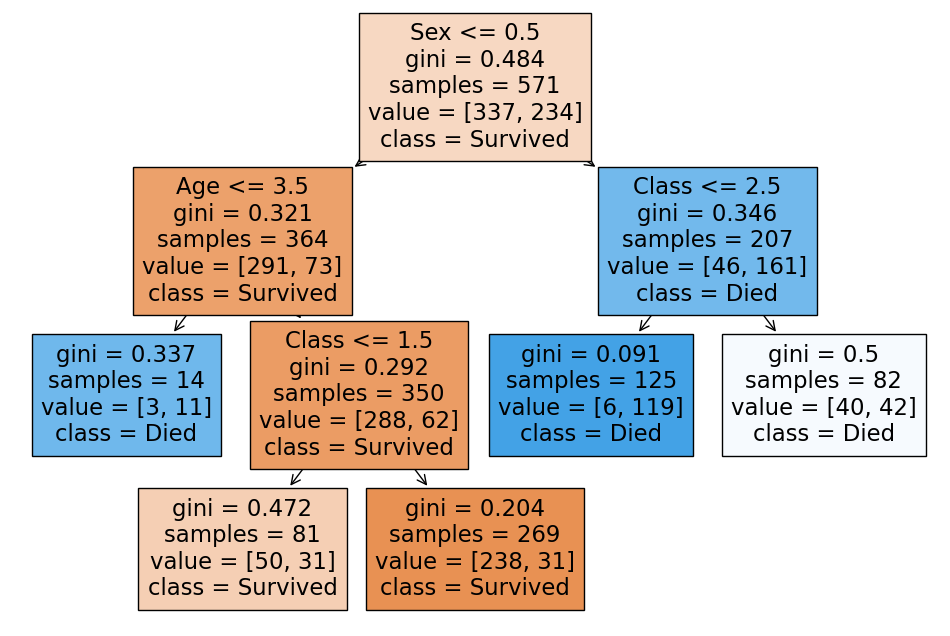

In [5]:
# Interesting columns and target (X and y)
X = df_titanic[['Sex', 'Age', 'Class']]
y = df_titanic['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the tree
classifier = DecisionTreeClassifier(min_impurity_decrease=0.01, max_depth=5, random_state=42)
classifier.fit(X_train, y_train)

# Create prediction
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

## Create tree file
#file = open("./titanic_trees/titanic_tree.dot", "w")
#tree.export_graphviz(classifier, out_file=file, feature_names=X.columns, class_names=['Survived', 'Died'])
#file.close()

# Plot tree
plt.figure(figsize=(12, 8))
plot_tree(classifier, feature_names=X.columns, class_names=['Survived', 'Died'], filled=True)
plt.show()

              precision    recall  f1-score   support

           0       0.78      0.79      0.78        87
           1       0.67      0.64      0.65        56

    accuracy                           0.73       143
   macro avg       0.72      0.72      0.72       143
weighted avg       0.73      0.73      0.73       143

Compared to the previous tree, it predicts very similar.


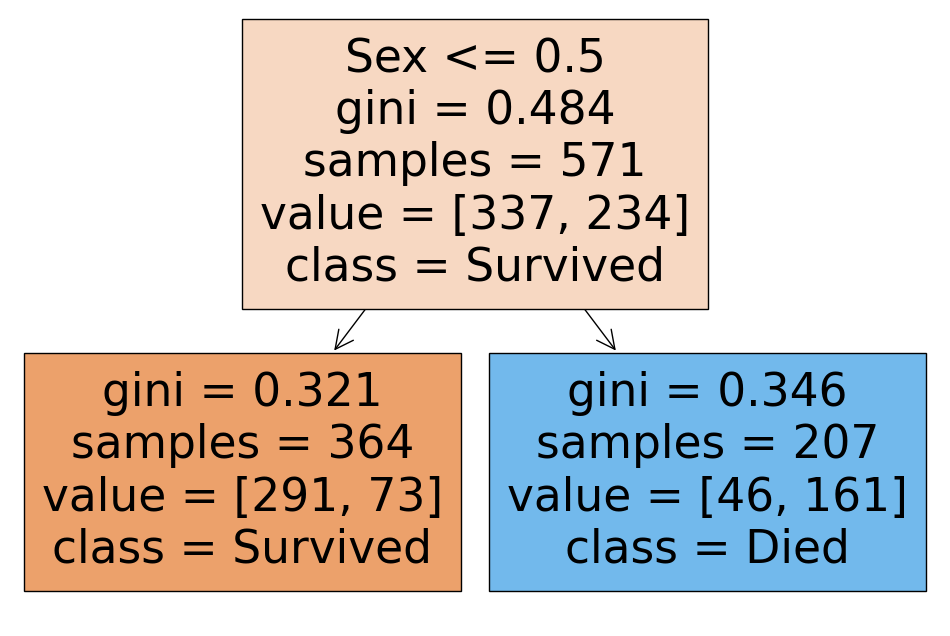

In [6]:
# Training the tree
classifier = DecisionTreeClassifier(min_impurity_decrease=0.01, max_depth=1, random_state=42)
classifier.fit(X_train, y_train)

# Create prediction
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print("Compared to the previous tree, it predicts very similar.")

## Create tree file
#file = open("./titanic_trees/shallow_titanic_tree.dot", "w")
#tree.export_graphviz(classifier, out_file=file, feature_names=X.columns, class_names=['Survived', 'Died'])
#file.close()

# Plot tree
plt.figure(figsize=(12, 8))
plot_tree(classifier, feature_names=X.columns, class_names=['Survived', 'Died'], filled=True)
plt.show()

### Resning av ov4-breast-cancer.csv

In [7]:
"""
ov4-breast-cancer - Renser ved å erstatte NaN med median
"""
df_breast_cancer = pd.read_csv('../Øving4/ov4-breast-cancer.csv') # The file is in the Øving4 folder
df_breast_cancer = clean_replace_question_mark_with_median(df_breast_cancer)
df_breast_cancer

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nuclei,bland_chrom,norm_nucleoli,mitoses,classes
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
696,888820,5,10,10,3,7,3.0,8,10,2,1
697,897471,4,8,6,4,3,4.0,10,6,1,1


### Oppgave 2

#### KNN - Fra Øving 4

In [8]:
# Select the features and target from the dataset
X = df_breast_cancer.drop('classes', axis=1)
y = df_breast_cancer['classes']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Choosing k by square root of y_test
k = choose_k(y_test)

# Initialize and training the KNN classifier
knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Print k
print(f"k: {k}")

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
c_m = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c_m)

# True Positive Rate
true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])

# True Negative Rate
true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])

# Accuracy
accuracy = (c_m[1][1] + c_m[0][0]) / (c_m[1][1] + c_m[1][0] + c_m[0][1] + c_m[0][0])

print(f"\nTrue positive rate: {true_positive_rate:.2f}")
print(f"True negative rate: {true_negative_rate:.2f}")
print(f"Accuracy: {accuracy:.2f}")


k: 11

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        95
           1       0.98      0.96      0.97        45

    accuracy                           0.98       140
   macro avg       0.98      0.97      0.98       140
weighted avg       0.98      0.98      0.98       140

Confusion Matrix:
[[94  1]
 [ 2 43]]

True positive rate: 0.98
True negative rate: 0.98
Accuracy: 0.98


#### Decision Tree

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        95
           1       0.93      0.93      0.93        45

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

Compared to my last answer in last exercise, the KNN model performs slightly better.


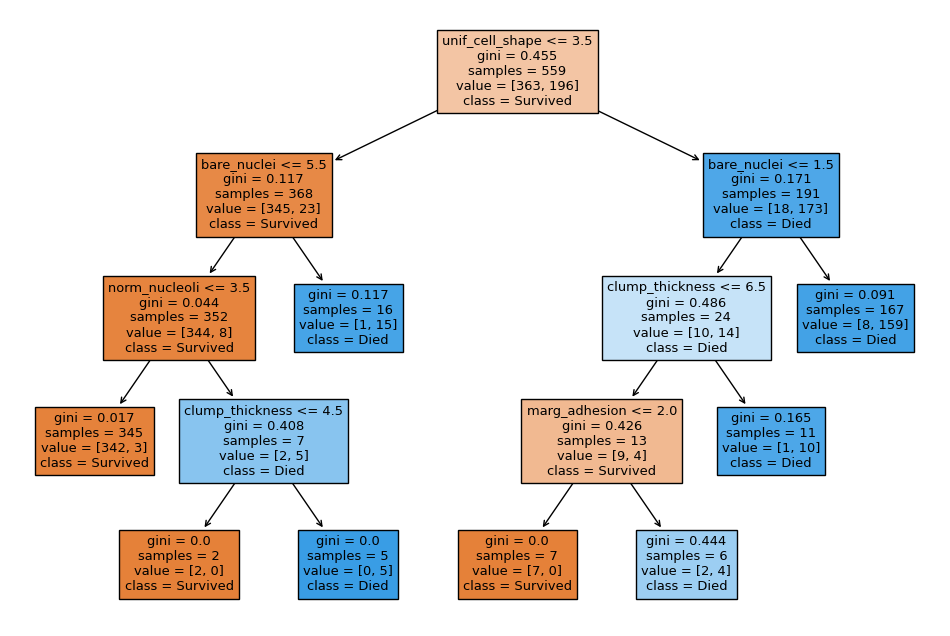

In [13]:
# Select the features and target from the dataset
X = df_breast_cancer.drop('classes', axis=1)
y = df_breast_cancer['classes']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the tree
classifier = DecisionTreeClassifier(min_impurity_decrease=0.004, max_depth=5, random_state=42)
classifier.fit(X_train, y_train)

# Create prediction
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print("Compared to my last answer in last exercise, the KNN model performs slightly better.")

## Create tree file
#file = open("./breast_cancer_trees/breast_cancer_tree.dot", "w")
#tree.export_graphviz(classifier, out_file=file, feature_names=X.columns, class_names=['Benign', 'Maligent'])
#file.close()

# Plot tree
plt.figure(figsize=(12, 8))
plot_tree(classifier, feature_names=X.columns, class_names=['Survived', 'Died'], filled=True)
plt.show()

### Rensing av boston-housing-reduced.csv

In [10]:
"""
boston-housing-reduced - Renser ved å fjerne rader med NaN verdier
"""
df_boston_housing_reduced = pd.read_csv('boston-housing-reduced.csv')
df_boston_housing_reduced

,RM,RAD,INDUS,TAX,MEDV
0,6.575,1,2.31,296,24.0
1,6.421,2,7.07,242,21.6
2,7.185,2,7.07,242,34.7
3,6.998,3,2.18,222,33.4
4,7.147,3,2.18,222,36.2
...,...,...,...,...,...
481,6.593,1,11.93,273,22.4
482,6.120,1,11.93,273,20.6
483,6.976,1,11.93,273,23.9
484,6.794,1,11.93,273,22.0


### Oppgave 3

R2 score: 0.6577
Mean squared error: 27.1989
Mean absolute error: 3.6625
The model demonstrates moderate predictive power, explaining about 66% of the variance in housing prices.


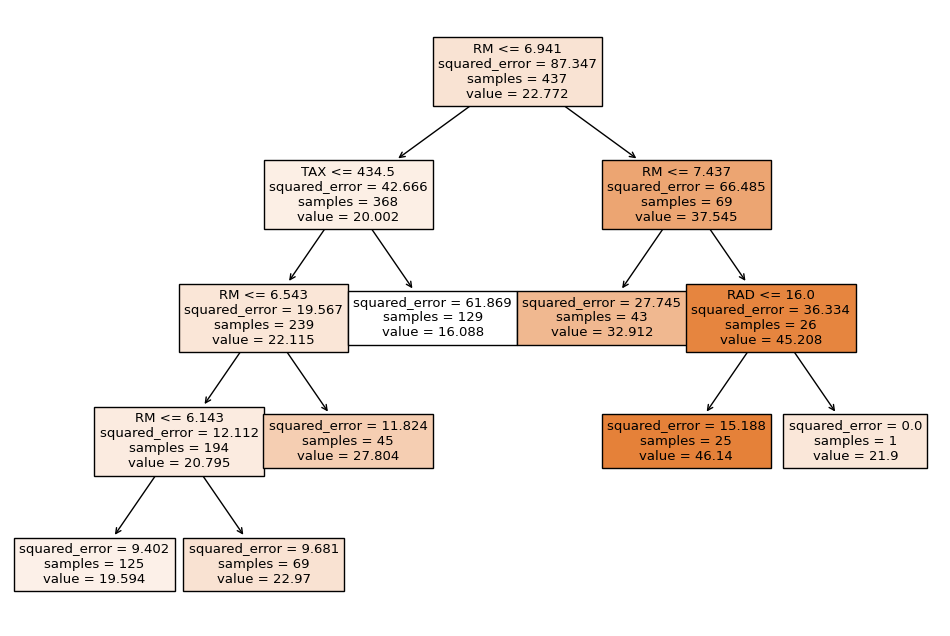

In [14]:
# Interesting features and target
X = df_boston_housing_reduced[['RM', 'RAD', 'INDUS', 'TAX']]
y = df_boston_housing_reduced['MEDV']

# Splitting into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Training regressor
regressor = DecisionTreeRegressor(min_impurity_decrease=1, random_state=42)
regressor.fit(X_train, y_train)

# Create prediction
y_pred = regressor.predict(X_test)

# Evaluate prediction
score = regressor.score(X_test, y_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Totally unnecessary if sentence
if score == r2:
    print(f"R2 score: {r2:.4f}")
else:
    print(f"Score: {score:.4f}")
    print(f"R2 score: {r2:.4f}")
print(f"Mean squared error: {mse:.4f}")
print(f"Mean absolute error: {mae:.4f}")

print("The model demonstrates moderate predictive power, explaining about 66% of the variance in housing prices.")

## Create regression tree file
#file = open("./boston_housing_regression_trees/boston_housing_regression_tree.dot", "w")
#tree.export_graphviz(regressor, out_file=file, feature_names=X.columns)
#file.close()

# Plot tree
plt.figure(figsize=(12, 8))
plot_tree(regressor, feature_names=X.columns, filled=True)
plt.show()